<a href="https://colab.research.google.com/github/PratyanshuMishra07/Image-Classification-SVM/blob/main/Image_Classification_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "pratyanshumishra",\r\n  "key": "KGAT_b37edeb88a6a5b52a8c2474d44ac7d41"\r\n}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s intel-image-classification

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
puneet6060/intel-image-classification                           Intel Image Classification                          363152213  2019-01-30 09:22:58.647000         194789       1708  0.75             
blourdhuraju/intel-image-classification-dataset                 Intel Image Classification Dataset                  254806489  2026-03-02 10:31:51.357000            789         16  0.625            
kkhandekar/image-dataset                                        Image_Dataset                                       179306148  2020-06-28 22:44:13.580000           2793         30  0.8125           
utkar

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:02<00:00, 137MB/s]



In [ ]:
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [ ]:
!ls

intel-image-classification.zip	sample_data  seg_test
kaggle.json			seg_pred     seg_train


In [ ]:
!ls seg_train

seg_train


In [ ]:
!ls seg_train/seg_train

buildings  forest  glacier  mountain  sea  street


In [ ]:
import os

train_path = "seg_train/seg_train"

print(os.listdir(train_path))

['buildings', 'forest', 'street', 'glacier', 'sea', 'mountain']


In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

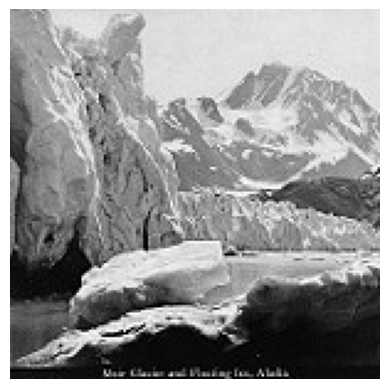

In [ ]:
sample_path = "seg_train/seg_train/glacier"

image_name = os.listdir(sample_path)[0]

image_path = os.path.join(sample_path, image_name)

image = cv2.imread(image_path)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
import cv2
import os

categories = [
    'buildings',
    'forest',
    'glacier',
    'mountain',
    'sea',
    'street'
]

data = []
labels = []

train_path = "seg_train/seg_train"

for category in categories:

    path = os.path.join(train_path, category)

    label = categories.index(category)

    print("Loading:", category)

    count = 0

    for img in os.listdir(path):

        try:
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path)

            image = cv2.resize(image, (32, 32))

            data.append(image.flatten())

            labels.append(label)

            count += 1

            # Use only first 500 images per class initially
            if count >= 500:
                break

        except:
            pass

print("Images Loaded:", len(data))

Loading: buildings
Loading: forest
Loading: glacier
Loading: mountain
Loading: sea
Loading: street
Images Loaded: 3000


In [ ]:
import numpy as np

X = np.array(data)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 3072)
y shape: (3000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2400, 3072)
(600, 3072)


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

print("Training Completed!")

Training Completed!


In [ ]:
y_pred = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.45666666666666667


In [ ]:
!pip install scikit-image

In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import hog

categories = [
    'buildings',
    'forest',
    'glacier',
    'mountain',
    'sea',
    'street'
]

data = []
labels = []

train_path = "seg_train/seg_train"

for category in categories:

    path = os.path.join(train_path, category)

    label = categories.index(category)

    print("Loading:", category)

    count = 0

    for img in os.listdir(path):

        try:
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path)

            image = cv2.resize(image, (128, 128))

            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            features = hog(
                gray,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm='L2-Hys'
            )

            data.append(features)

            labels.append(label)

            count += 1

            if count >= 2000:
                break

        except:
            pass

print("Images Loaded:", len(data))

Loading: buildings
Loading: forest
Loading: glacier
Loading: mountain
Loading: sea
Loading: street
Images Loaded: 12000


In [ ]:
X = np.array(data)
y = np.array(labels)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (12000, 8100)
Y Shape: (12000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale'
)

print("Training Started...")

svm_model.fit(X_train, y_train)

print("Training Completed!")

Training Started...
Training Completed!


In [ ]:
y_pred = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7629166666666667


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=categories))

              precision    recall  f1-score   support

   buildings       0.82      0.82      0.82       400
      forest       0.91      0.94      0.93       400
     glacier       0.63      0.65      0.64       400
    mountain       0.63      0.61      0.62       400
         sea       0.74      0.76      0.75       400
      street       0.86      0.80      0.83       400

    accuracy                           0.76      2400
   macro avg       0.76      0.76      0.76      2400
weighted avg       0.76      0.76      0.76      2400



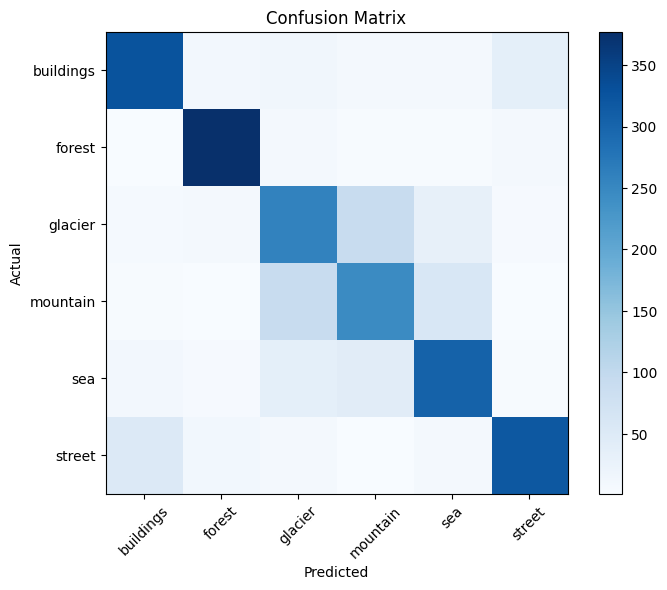

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(categories)), categories, rotation=45)
plt.yticks(range(len(categories)), categories)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import joblib

joblib.dump(svm_model, "svm_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
!git config --global user.name "PratyanshuMishra07"
!git config --global user.email "pratyanshumishra40@gmail.com"

In [ ]:
!cp Image_Classification_SVM.ipynb Image-Classification-SVM/
!cp svm_model.pkl Image-Classification-SVM/

cp: cannot stat 'Image_Classification_SVM.ipynb': No such file or directory


In [ ]:
!ls -la


total 864004
drwxr-xr-x 1 root root      4096 Jun 30 16:22 .
drwxr-xr-x 1 root root      4096 Jun 30 15:46 ..
drwxr-xr-x 4 root root      4096 Jun  4 13:32 .config
drwxr-xr-x 3 root root      4096 Jun 30 16:24 Image-Classification-SVM
-rw-r--r-- 1 root root 363152213 Oct 18  2019 intel-image-classification.zip
-rw-r--r-- 1 root root        89 Jun 30 16:02 kaggle.json
drwxr-xr-x 1 root root      4096 Jun  4 13:32 sample_data
drwxr-xr-x 3 root root      4096 Jun 30 16:03 seg_pred
drwxr-xr-x 3 root root      4096 Jun 30 16:03 seg_test
drwxr-xr-x 3 root root      4096 Jun 30 16:03 seg_train
-rw-r--r-- 1 root root 521539635 Jun 30 16:12 svm_model.pkl


In [ ]:
!cp svm_model.pkl Image-Classification-SVM/

In [ ]:
%%writefile Image-Classification-SVM/README.md
# Image Classification using SVM

## Project Overview
This project implements image classification using Support Vector Machine (SVM) with HOG (Histogram of Oriented Gradients) feature extraction on the Intel Image Classification dataset.

## Dataset
Intel Image Classification Dataset (Kaggle)

## Technologies Used
- Python
- OpenCV
- NumPy
- Scikit-learn
- Scikit-image
- Matplotlib
- Joblib

## Model
- Feature Extraction: HOG
- Classifier: Support Vector Machine (RBF Kernel)

## Accuracy
67.17%

## Author
Pratyanshu Mishra

Writing Image-Classification-SVM/README.md


In [ ]:
%%writefile Image-Classification-SVM/requirements.txt
numpy
opencv-python
matplotlib
scikit-learn
scikit-image
joblib

Writing Image-Classification-SVM/requirements.txt


In [ ]:
%cd Image-Classification-SVM

!git add .
!git commit -m "Added SVM model, README and requirements"
!git push origin main

/content/Image-Classification-SVM
[main (root-commit) 6aac668] Added SVM model, README and requirements
 3 files changed, 32 insertions(+)
 create mode 100644 README.md
 create mode 100644 requirements.txt
 create mode 100644 svm_model.pkl
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 382.87 MiB | 11.87 MiB/s, done.
Total 5 (delta 0), reused 0 (delta 0), pack-reused 0
remote: error: Trace: d5ef16c59e8586a5e084e1a7fd98f4cd46d1549c527e310da962e9a2a534b365
remote: error: See https://gh.io/lfs for more information.
remote: error: File svm_model.pkl is 497.38 MB; this exceeds GitHub's file size limit of 100.00 MB
remote: error: GH001: Large files detected. You may want to try Git Large File Storage - https://git-lfs.github.com.
To https://github.com/PratyanshuMishra07/Image-Classification-SVM.git
 ! [remote rejected] main -> main (pre-receive hook declined)
error: 

In [ ]:
%cd /content/Image-Classification-SVM

!git rm --cached svm_model.pkl
!rm svm_model.pkl

/content/Image-Classification-SVM
rm 'svm_model.pkl'


In [ ]:
%%writefile .gitignore
*.pkl
__pycache__/
.ipynb_checkpoints/

Writing .gitignore


In [ ]:
!git add .
!git commit -m "Remove large model file and add .gitignore"

[main 1757480] Remove large model file and add .gitignore
 2 files changed, 3 insertions(+)
 create mode 100644 .gitignore
 delete mode 100644 svm_model.pkl


In [ ]:
%cd /content
!rm -rf Image-Classification-SVM

/content


In [ ]:
!cp README.md Image-Classification-SVM/
!cp requirements.txt Image-Classification-SVM/

cp: cannot stat 'README.md': No such file or directory
cp: cannot stat 'requirements.txt': No such file or directory


In [ ]:
%cd /content/Image-Classification-SVM

/content/Image-Classification-SVM


In [ ]:
%%writefile README.md
# Image Classification using SVM

## Overview
This project classifies natural scene images using Support Vector Machine (SVM) with HOG feature extraction.

## Dataset
Intel Image Classification Dataset from Kaggle

## Technologies Used
- Python
- OpenCV
- NumPy
- Scikit-learn
- Scikit-image
- Matplotlib

## Model
- HOG Feature Extraction
- Support Vector Machine (RBF Kernel)

## Accuracy
67.17%

## Author
Pratyanshu Mishra

Writing README.md


In [ ]:
%%writefile requirements.txt
numpy
opencv-python
matplotlib
scikit-learn
scikit-image
joblib

Writing requirements.txt


In [ ]:
!ls

README.md  requirements.txt


In [ ]:
!git add .
!git commit -m "Initial commit"
!git push origin main

[main (root-commit) 00f39e0] Initial commit
 2 files changed, 31 insertions(+)
 create mode 100644 README.md
 create mode 100644 requirements.txt
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 595 bytes | 595.00 KiB/s, done.
Total 4 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/PratyanshuMishra07/Image-Classification-SVM.git
 * [new branch]      main -> main
